# Factores desencadenantes predominantes en registros de ideación suicida

**Población:** adolescentes de 12 a 17 años en Bogotá  
**Periodo:** 2017-2025  
**Autores:** Paola Yate Cuervo y Wilber Jonatan Plazas Murcia

**Pregunta principal:** ¿Qué factores desencadenantes predominan en los registros de ideación suicida notificados en adolescentes de 12 a 17 años en Bogotá entre 2017 y 2025?

El notebook organiza la ejecución de las funciones definidas en `src/`. Los factores no son excluyentes: una notificación puede registrar más de uno y, por tanto, sus proporciones no tienen que sumar 100 %.

## 1. Configuración e importación de funciones

In [1]:
from pathlib import Path
import sys

from IPython.display import display

# Permite ejecutar el notebook desde la raíz del proyecto o desde notebooks/.
RAIZ_PROYECTO = Path.cwd()
if not (RAIZ_PROYECTO / "src").exists():
    RAIZ_PROYECTO = RAIZ_PROYECTO.parent

if str(RAIZ_PROYECTO) not in sys.path:
    sys.path.insert(0, str(RAIZ_PROYECTO))

from src.datos import FACTORES, cargar_datos, filtrar_poblacion, validar_datos
from src.indicadores import calcular_indicadores, generar_ranking
from src.estadistica import comparar_mcnemar, prueba_cochran
from src.visualizacion import grafico_evolucion_top3, grafico_mapa_calor_anual, grafico_ranking_global

ANO_INICIAL = 2017
ANO_FINAL = 2025
RUTA_DATOS = RAIZ_PROYECTO / "data" / "osb_salud_mental_ideacion_e_intento.csv"

print(f"Periodo configurado: {ANO_INICIAL}-{ANO_FINAL}")
print(f"Archivo de datos: {RUTA_DATOS}")

Periodo configurado: 2017-2025
Archivo de datos: /workspace/scratch/037362ef714b/final_entregable.OrlonU/Proyecto_analitica_datos/data/osb_salud_mental_ideacion_e_intento.csv


## 2. Carga, filtro y validación de los datos

La validación detiene el análisis si encuentra columnas ausentes, valores nulos, factores diferentes de 0 o 1, o años sin registros dentro del periodo solicitado.

In [2]:
# Se cargan únicamente las doce columnas necesarias.
datos = cargar_datos(RUTA_DATOS)

# Se seleccionan la conducta, el ciclo vital y el periodo definidos.
datos_estudio = filtrar_poblacion(datos, ANO_INICIAL, ANO_FINAL)

# Se revisan nulos y se confirma que los factores solo contengan 0 o 1.
reporte_calidad = validar_datos(datos_estudio)

print(f"Registros cargados: {len(datos)}")
print(f"Registros seleccionados: {len(datos_estudio)}")
display(reporte_calidad)
display(datos_estudio.head())

Registros cargados: 274648
Registros seleccionados: 53887


,Valores faltantes
ano_notificacion,0
enfermedades_dolorosas,0
maltrato_sexual,0
muerte_familiar,0
conflicto_pareja,0
problemas_economicos,0
esc_educ,0
problemas_juridicos,0
problemas_laborales,0
suicidio_amigo,0


,ano_notificacion,enfermedades_dolorosas,maltrato_sexual,muerte_familiar,conflicto_pareja,problemas_economicos,esc_educ,problemas_juridicos,problemas_laborales,suicidio_amigo
109,2022,0,0,1,0,0,1,0,0,0
110,2019,0,1,1,0,0,1,0,0,0
114,2018,0,0,0,0,0,0,0,0,0
115,2023,0,0,0,0,0,0,0,0,0
119,2025,0,0,0,0,0,1,0,0,0


## 3. Análisis descriptivo

Se calculan la frecuencia y proporción global, los resultados por año y los tres factores con mayor proporción anual. El ranking usa como criterio principal la proporción global y como criterio secundario los años en el top 3; los empates exactos se resuelven alfabéticamente. En el corte anual también se usa el orden alfabético para resolver empates y se conservan exactamente tres factores.

In [3]:
resumen_global, resumen_anual, top3_anual = calcular_indicadores(datos_estudio)
numero_anos = datos_estudio["ano_notificacion"].nunique()
ranking = generar_ranking(resumen_global, top3_anual, numero_anos)

print("Resumen global")
resumen_global_mostrar = resumen_global.copy()
resumen_global_mostrar["Proporción (%)"] = (resumen_global_mostrar.pop("Proporción") * 100).round(2)
display(resumen_global_mostrar)

print("Frecuencias anuales")
tabla_frecuencias = resumen_anual.pivot(index="Año", columns="factor", values="Frecuencia")
display(tabla_frecuencias)

print("Top 3 de cada año")
top3_mostrar = top3_anual[["Año", "Posición anual", "Factor", "Frecuencia", "Proporción"]].copy()
top3_mostrar["Proporción (%)"] = (top3_mostrar.pop("Proporción") * 100).round(2)
display(top3_mostrar)

print("Ranking final")
ranking_mostrar = ranking.drop(columns="factor").copy()
ranking_mostrar["Proporción (%)"] = (ranking_mostrar.pop("Proporción") * 100).round(2)
ranking_mostrar["Persistencia (%)"] = (ranking_mostrar.pop("Persistencia") * 100).round(2)
display(ranking_mostrar)

Resumen global
Frecuencias anuales
Top 3 de cada año
Ranking final


,factor,Factor,Frecuencia,Proporción (%)
0,esc_educ,Problemas escolares,27243,50.56
1,maltrato_sexual,Maltrato sexual,6899,12.80
2,conflicto_pareja,Conflicto de pareja,3832,7.11
3,muerte_familiar,Muerte de un familiar,2965,5.50
4,problemas_economicos,Problemas económicos,1751,3.25
5,enfermedades_dolorosas,Enfermedades dolorosas,956,1.77
6,suicidio_amigo,Suicidio de un amigo,598,1.11
7,problemas_laborales,Problemas laborales,491,0.91
8,problemas_juridicos,Problemas jurídicos,199,0.37


factor,conflicto_pareja,enfermedades_dolorosas,esc_educ,maltrato_sexual,muerte_familiar,problemas_economicos,problemas_juridicos,problemas_laborales,suicidio_amigo
Año,,,,,,,,,
2017,11,2,22,11,2,4,0,0,1
2018,699,21,1044,629,116,91,8,11,44
2019,266,68,2288,1216,233,121,28,5,64
2020,210,83,1922,796,183,171,28,9,30
2021,339,121,2938,776,354,267,29,37,52
2022,449,146,5652,920,551,302,25,59,113
2023,583,202,4875,868,529,298,22,111,97
2024,673,171,4213,855,495,298,36,158,107
2025,602,142,4289,828,502,199,23,101,90


,Año,Posición anual,Factor,Frecuencia,Proporción (%)
0,2017,1,Problemas escolares,22,0.87
1,2017,2,Conflicto de pareja,11,0.43
2,2017,3,Maltrato sexual,11,0.43
3,2018,1,Problemas escolares,1044,29.09
4,2018,2,Conflicto de pareja,699,19.48
5,2018,3,Maltrato sexual,629,17.53
6,2019,1,Problemas escolares,2288,61.31
7,2019,2,Maltrato sexual,1216,32.58
8,2019,3,Conflicto de pareja,266,7.13
9,2020,1,Problemas escolares,1922,65.22


,Posición,Factor,Frecuencia,Años en top 3,Prioridad analítica,Proporción (%),Persistencia (%)
0,1,Problemas escolares,27243,9,Alta,50.56,100.00
1,2,Maltrato sexual,6899,9,Alta,12.80,100.00
2,3,Conflicto de pareja,3832,7,Alta,7.11,77.78
3,4,Muerte de un familiar,2965,2,Media,5.50,22.22
4,5,Problemas económicos,1751,0,Media,3.25,0.00
5,6,Enfermedades dolorosas,956,0,Media,1.77,0.00
6,7,Suicidio de un amigo,598,0,Baja,1.11,0.00
7,8,Problemas laborales,491,0,Baja,0.91,0.00
8,9,Problemas jurídicos,199,0,Baja,0.37,0.00


## 4. Pruebas estadísticas

La **Q de Cochran** evalúa si las proporciones de los nueve factores son iguales. Si el resultado es significativo, **McNemar** compara por parejas los tres factores principales y ajusta los p-valores mediante Holm. Estas pruebas identifican diferencias estadísticas, pero no demuestran causalidad.

In [4]:
resultado_cochran = prueba_cochran(datos_estudio, FACTORES)
display(resultado_cochran)

factores_top3 = ranking.head(3)["factor"].tolist()

if resultado_cochran.loc[0, "p-valor"] < 0.05:
    resultados_mcnemar = comparar_mcnemar(datos_estudio, factores_top3)
    display(resultados_mcnemar)

,Estadístico Q,Grados de libertad,p-valor,N utilizado,Decisión
0,124083.018397,8,0.0,53887,Rechazar H0


,Factor A,Factor B,Estadístico,p-valor,N utilizado,p-valor ajustado (Holm),Decisión
0,Problemas escolares,Maltrato sexual,13784.479682,0.000000e+00,53887,0.000000e+00,Rechazar H0
1,Problemas escolares,Conflicto de pareja,18847.477388,0.000000e+00,53887,0.000000e+00,Rechazar H0
2,Maltrato sexual,Conflicto de pareja,930.451945,2.355347e-204,53887,2.355347e-204,Rechazar H0


## 5. Visualizaciones

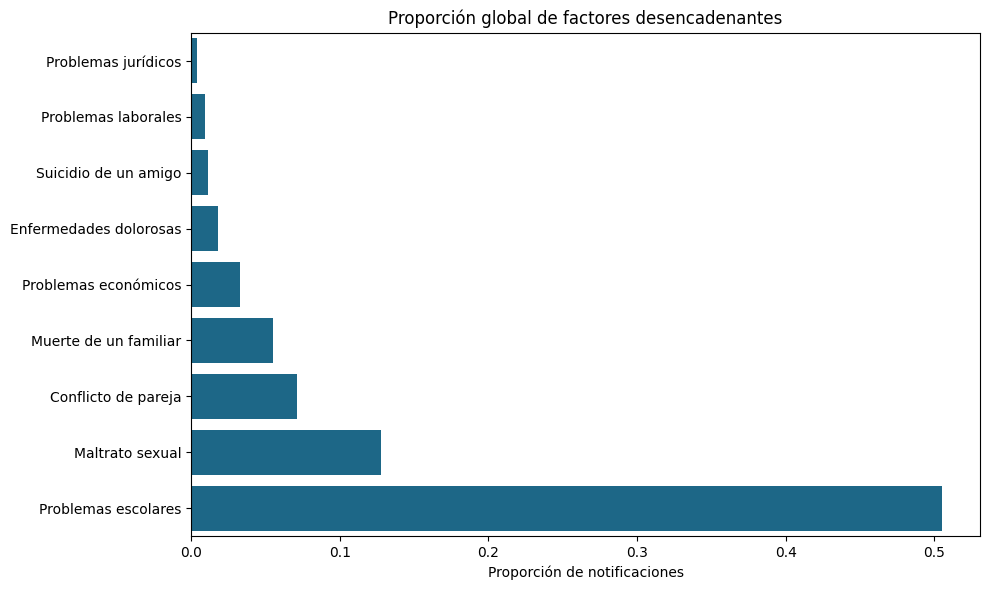

In [5]:
grafico_ranking_global(ranking)

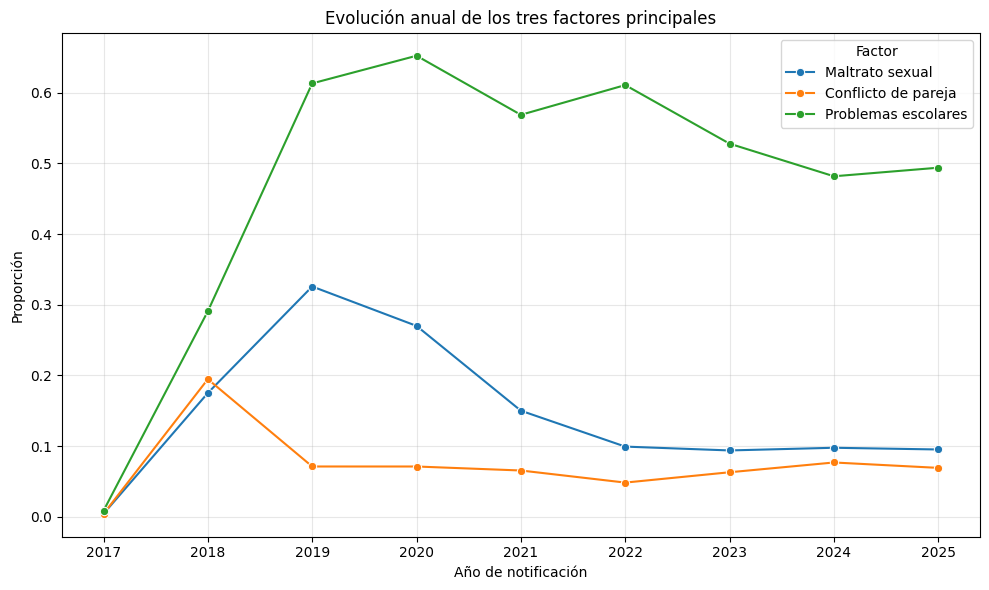

In [6]:
grafico_evolucion_top3(resumen_anual, factores_top3)

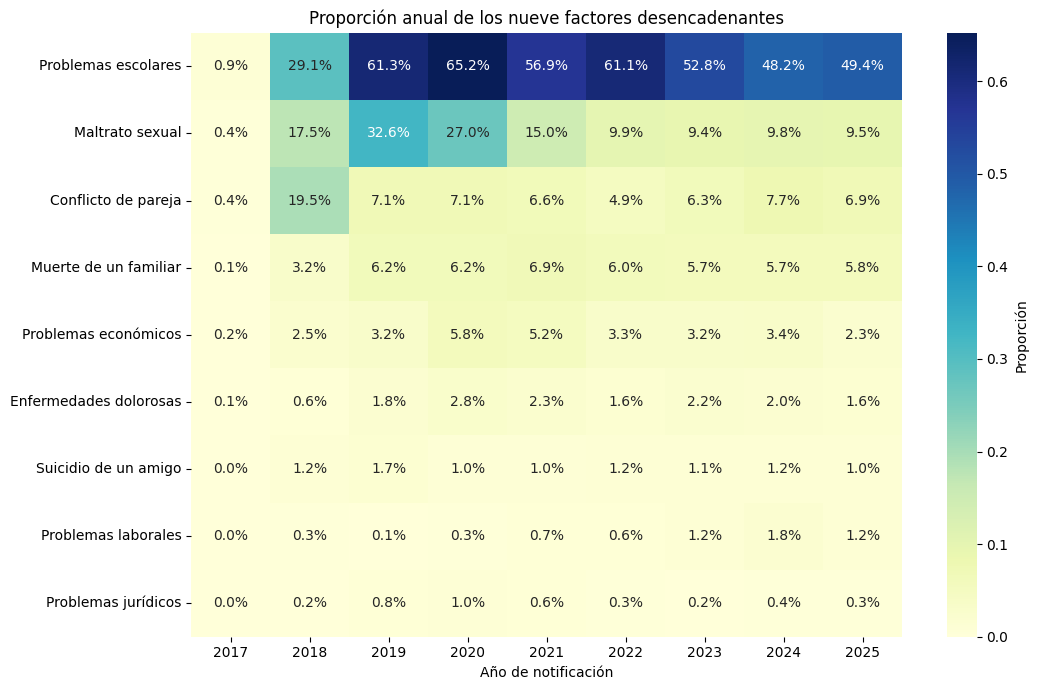

In [7]:
grafico_mapa_calor_anual(resumen_anual)

## 6. Verificación del escenario de fallo

La ejecución normal del notebook evidencia el funcionamiento con una estructura válida. Aquí se comprueba únicamente el escenario pactado de control de fallo, eliminando deliberadamente una columna requerida.

In [9]:
# Escenario 2: se elimina una variable para comprobar el control de estructura.
datos_incompletos = datos_estudio.drop(columns=["maltrato_sexual"])

try:
    validar_datos(datos_incompletos)
except ValueError as error:
    print(f"Escenario 2 superado: {error}")

Escenario 2 superado: Faltan columnas requeridas: maltrato_sexual


## 7. Respuesta a la pregunta principal

In [10]:
principales = ranking.head(3)[["Factor", "Años en top 3", "Proporción"]]

print("Los tres factores que deben priorizarse para el análisis son:")
for _, fila in principales.iterrows():
    print(
        f"- {fila['Factor']}: proporción global de {fila['Proporción']:.2%} "
        f"y presencia en el top 3 durante {int(fila['Años en top 3'])} de {numero_anos} años."
    )

print()
print("La priorización es descriptiva y no representa causalidad ni prioridad clínica.")

Los tres factores que deben priorizarse para el análisis son:
- Problemas escolares: proporción global de 50.56% y presencia en el top 3 durante 9 de 9 años.
- Maltrato sexual: proporción global de 12.80% y presencia en el top 3 durante 9 de 9 años.
- Conflicto de pareja: proporción global de 7.11% y presencia en el top 3 durante 7 de 9 años.

La priorización es descriptiva y no representa causalidad ni prioridad clínica.
